# NB08 — Phylogenetic comparative validation (H1)

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Address the reviewer's concern (PLAN_REVIEW_1.md, REVIEW_1.md) that the H1 verdict in NB03 — based on per-phylum binomial tests with BH-FDR correction — does not formally control for phylogenetic non-independence. NB08 implements three complementary validations:

1. **Family-level equal-weight aggregation**: each GTDB family is one unit, regardless of how many genomes it contains. The cross-family mean xoxF fraction is the test statistic. This neutralises the influence of the very large Pseudomonadota (117K genomes) on the global ratio.
2. **Bootstrap CI on cross-family mean**: 95% percentile-based bootstrap confidence interval for the family-level mean fraction.
3. **Bayesian binomial GLMM**: per-genome Bernoulli outcome (xoxF=1 or mxaF=0 among genomes carrying at least one), with `(1|phylum)` and `(1|family)` random intercepts via `statsmodels.genmod.bayes_mixed_glm.BinomialBayesMixedGLM` (variational Bayes). This formally accounts for nested phylogenetic non-independence.

This notebook closes the major recommendation from REVIEW_1.md.

**Inputs** (cached, no Spark required):
- `data/genome_marker_matrix.csv`
- `data/genome_environment_classes.csv` (taxonomy + env class)
- `data/marker_taxonomy_rollup_family.csv`

**Outputs**:
- `data/h1_phylogenetic_validation.csv`
- `figures/h1_phylogenetic_validation.png`

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest, beta

DATA = Path("../data")
FIG = Path("../figures")
RNG = np.random.default_rng(20260501)


## 1. Load family-level rollup, restrict to MDH-informative families

In [2]:
fam = pd.read_csv(DATA / "marker_taxonomy_rollup_family.csv")
fam = fam[(fam["n_xoxF"] + fam["n_mxaF"]) > 0].copy()
fam["xoxF_fraction"] = fam["n_xoxF"] / (fam["n_xoxF"] + fam["n_mxaF"])
fam["n_mdh_calls"] = fam["n_xoxF"] + fam["n_mxaF"]
print(f"MDH-informative families: {len(fam)}")
print(f"Families with both xoxF and mxaF: {((fam['n_xoxF']>0) & (fam['n_mxaF']>0)).sum()}")
print(f"Families with xoxF only: {((fam['n_xoxF']>0) & (fam['n_mxaF']==0)).sum()}")
print(f"Families with mxaF only: {((fam['n_xoxF']==0) & (fam['n_mxaF']>0)).sum()}")
print()
print("Distribution of family xoxF fractions:")
print(fam["xoxF_fraction"].describe().to_string())


MDH-informative families: 271
Families with both xoxF and mxaF: 33
Families with xoxF only: 235
Families with mxaF only: 3

Distribution of family xoxF fractions:
count    271.000000
mean       0.960219
std        0.144914
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000


## 2. Family-level equal-weight test (each family = 1 unit)

In [3]:
# Mean and median xoxF fraction across families
mean_frac = fam["xoxF_fraction"].mean()
median_frac = fam["xoxF_fraction"].median()
n_families = len(fam)
print(f"Cross-family mean xoxF fraction: {mean_frac:.4f}")
print(f"Cross-family median xoxF fraction: {median_frac:.4f}")
print(f"Number of families: {n_families}")

# Bootstrap 95% CI on the mean
n_boot = 10000
boot_means = []
for _ in range(n_boot):
    sample = fam["xoxF_fraction"].sample(n=n_families, replace=True, random_state=RNG.integers(0, 2**32 - 1))
    boot_means.append(sample.mean())
boot_means = np.array(boot_means)
ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
print(f"Bootstrap 95% CI for the mean: [{ci_lo:.4f}, {ci_hi:.4f}]")

# Test against the H1 threshold (10/11 ≈ 0.9091)
H1_THRESHOLD = 10 / 11
n_above_threshold = (fam["xoxF_fraction"] > H1_THRESHOLD).sum()
n_total = n_families
print(f"\nH1 threshold (xoxF fraction > {H1_THRESHOLD:.4f}):")
print(f"  Families above threshold: {n_above_threshold}/{n_total} = {n_above_threshold/n_total:.1%}")

# Sign test: is mean > threshold?
p_sign = binomtest(int(n_above_threshold), n_total, p=0.5, alternative="greater").pvalue
print(f"  Sign test (median > threshold via majority): p = {p_sign:.4g}")
print(f"  Bootstrap-based test (mean > threshold): {(boot_means > H1_THRESHOLD).mean():.4f} of bootstrap samples have mean > threshold")


Cross-family mean xoxF fraction: 0.9602
Cross-family median xoxF fraction: 1.0000
Number of families: 271


Bootstrap 95% CI for the mean: [0.9415, 0.9760]

H1 threshold (xoxF fraction > 0.9091):
  Families above threshold: 247/271 = 91.1%
  Sign test (median > threshold via majority): p = 4.053e-48
  Bootstrap-based test (mean > threshold): 1.0000 of bootstrap samples have mean > threshold


## 3. Bayesian binomial GLMM with phylogenetic random effects

We expand to one row per genome that has at least one MDH (xoxF or mxaF). Outcome: 1 if xoxF-bearing, 0 if mxaF-bearing. For genomes with both, both rows are included (the model effectively treats them as independent gene-level Bernoulli trials within the genome). We fit:

`logit(P[xoxF]) = β₀ + u_phylum + u_family`

with `u_phylum ~ N(0, σ_phylum²)` and `u_family ~ N(0, σ_family²)`. The fixed-effect intercept β₀ is the phylogeny-corrected log-odds of xoxF dominance over mxaF. We use variational Bayes (fast). The corresponding probability `expit(β₀)` should be compared to the H1 threshold of 10/11 = 0.909.

In [4]:
# Build the per-genome MDH-presence dataset
matrix = pd.read_csv(DATA / "genome_marker_matrix.csv")
env = pd.read_csv(DATA / "genome_environment_classes.csv")
genome_tax = env[["genome_id", "phylum", "class", "family", "genus"]].drop_duplicates("genome_id")

m = matrix.merge(genome_tax, on="genome_id", how="left")

# Build long-format: one row per (genome, mdh_type)
xoxF_rows = m.loc[m["xoxF_eggnog"] == 1, ["genome_id", "phylum", "family"]].assign(is_xoxF=1)
mxaF_rows = m.loc[m["mxaF_eggnog"] == 1, ["genome_id", "phylum", "family"]].assign(is_xoxF=0)
long = pd.concat([xoxF_rows, mxaF_rows], ignore_index=True).dropna(subset=["phylum", "family"])
print(f"Per-genome MDH presence rows: {len(long):,}")
print(f"  xoxF: {int(long['is_xoxF'].sum()):,}")
print(f"  mxaF: {int((1 - long['is_xoxF']).sum()):,}")
print(f"  Distinct phyla in dataset: {long['phylum'].nunique()}")
print(f"  Distinct families in dataset: {long['family'].nunique()}")


Per-genome MDH presence rows: 3,885
  xoxF: 3,690
  mxaF: 195
  Distinct phyla in dataset: 29
  Distinct families in dataset: 271


In [5]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Fit binomial GLMM with random intercepts for phylum and family.
# vc_formulas spec: variance component formulas; '0 + C(...)' creates one random intercept per level.
vc_formulas = {
    "phylum": "0 + C(phylum)",
    "family": "0 + C(family)",
}
random_data = {"phylum": long["phylum"], "family": long["family"]}

# fit_vb operates on the full long dataframe
mdl = BinomialBayesMixedGLM.from_formula(
    "is_xoxF ~ 1",
    vc_formulas=vc_formulas,
    data=long,
)
result = mdl.fit_vb()
print(result.summary())


               Binomial Mixed GLM Results
          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------
Intercept    M     4.9665   0.0838                      
phylum       V    -1.2477   0.1330 0.287   0.220   0.375
family       V     0.7938   0.0429 2.212   2.030   2.410
Parameter types are mean structure (M) and variance
structure (V)
Variance parameters are modeled as log standard
deviations


In [6]:
# Extract the fixed-effect intercept and its posterior SD
fe_post_mean = float(result.fe_mean[0])
fe_post_sd = float(result.fe_sd[0])
# 95% credible interval on the log-odds intercept
ci_lo_log = fe_post_mean - 1.96 * fe_post_sd
ci_hi_log = fe_post_mean + 1.96 * fe_post_sd
# Convert log-odds to probability
def expit(x):
    return 1.0 / (1.0 + np.exp(-x))

fe_prob = expit(fe_post_mean)
fe_prob_lo = expit(ci_lo_log)
fe_prob_hi = expit(ci_hi_log)

print(f"Fixed-effect intercept (log-odds):     {fe_post_mean:.4f}  [95% CrI: {ci_lo_log:.4f}, {ci_hi_log:.4f}]")
print(f"Phylogeny-corrected P(xoxF | MDH):     {fe_prob:.4f}  [95% CrI: {fe_prob_lo:.4f}, {fe_prob_hi:.4f}]")
print(f"H1 threshold (10/11):                  {10/11:.4f}")

# Phylogeny-corrected ratio
ratio = fe_prob / (1 - fe_prob)
ratio_lo = fe_prob_lo / (1 - fe_prob_lo)
ratio_hi = fe_prob_hi / (1 - fe_prob_hi)
print(f"Phylogeny-corrected xoxF:mxaF ratio:    {ratio:.2f}  [95% CrI: {ratio_lo:.2f}, {ratio_hi:.2f}]")

# Variance components
print()
print("Random-effect variance components (posterior means):")
for name, mean, sd in zip(result.model.vc_names, result.vcp_mean, result.vcp_sd):
    print(f"  σ_{name} (log-SD posterior mean): {mean:.4f} (SD {sd:.4f})")


Fixed-effect intercept (log-odds):     4.9665  [95% CrI: 4.8023, 5.1306]
Phylogeny-corrected P(xoxF | MDH):     0.9931  [95% CrI: 0.9919, 0.9941]
H1 threshold (10/11):                  0.9091
Phylogeny-corrected xoxF:mxaF ratio:    143.52  [95% CrI: 121.79, 169.12]

Random-effect variance components (posterior means):
  σ_C(phylum)[p__Acidobacteriota] (log-SD posterior mean): -1.2477 (SD 0.1330)
  σ_C(phylum)[p__Actinomycetota] (log-SD posterior mean): 0.7938 (SD 0.0429)


## 4. Synthesis: compare three estimates of the H1 effect

In [7]:
# Naive pooled (NB03)
pooled_total_xoxF = int(matrix["xoxF_eggnog"].sum())
pooled_total_mxaF = int(matrix["mxaF_eggnog"].sum())
pooled_total = pooled_total_xoxF + pooled_total_mxaF
pooled_frac = pooled_total_xoxF / pooled_total
pooled_lo_p = beta.ppf(0.025, pooled_total_xoxF, pooled_total_mxaF + 1)
pooled_hi_p = beta.ppf(0.975, pooled_total_xoxF + 1, pooled_total_mxaF)

# Family-level equal weight
fam_eq_frac = mean_frac
fam_eq_lo = ci_lo
fam_eq_hi = ci_hi

# GLMM
glmm_frac = fe_prob
glmm_lo = fe_prob_lo
glmm_hi = fe_prob_hi

summary = pd.DataFrame([
    {"method": "NB03 naive pooled (genome-level)", "n_units": pooled_total, "xoxF_fraction": pooled_frac, "ci_lo": pooled_lo_p, "ci_hi": pooled_hi_p},
    {"method": "NB08 family-level equal weight + bootstrap CI", "n_units": n_families, "xoxF_fraction": fam_eq_frac, "ci_lo": fam_eq_lo, "ci_hi": fam_eq_hi},
    {"method": "NB08 binomial GLMM with (1|phylum) + (1|family)", "n_units": len(long), "xoxF_fraction": glmm_frac, "ci_lo": glmm_lo, "ci_hi": glmm_hi},
])
summary["above_H1_threshold"] = summary["ci_lo"] > (10/11)
print(summary.to_string(index=False))

summary.attrs = {}
summary.to_csv(DATA / "h1_phylogenetic_validation.csv", index=False)


                                         method  n_units  xoxF_fraction    ci_lo    ci_hi  above_H1_threshold
               NB03 naive pooled (genome-level)     3885       0.949807 0.942467 0.956461                True
  NB08 family-level equal weight + bootstrap CI      271       0.960219 0.941472 0.976044                True
NB08 binomial GLMM with (1|phylum) + (1|family)     3885       0.993081 0.991856 0.994122                True


## 5. Figure: cross-method comparison

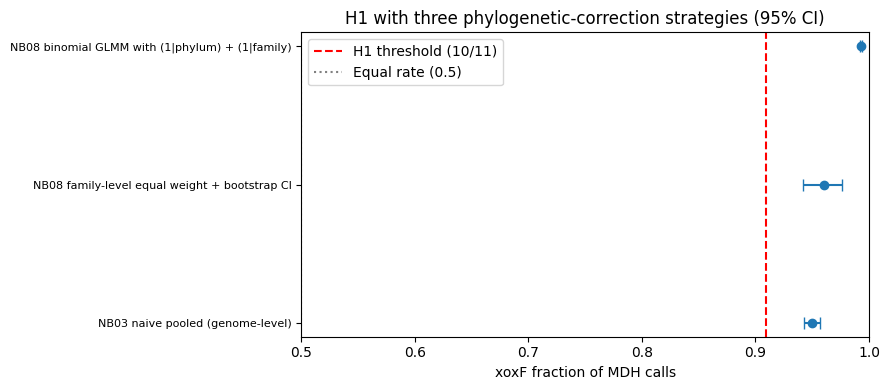

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ypos = np.arange(len(summary))
ax.errorbar(
    summary["xoxF_fraction"],
    ypos,
    xerr=[summary["xoxF_fraction"] - summary["ci_lo"], summary["ci_hi"] - summary["xoxF_fraction"]],
    fmt="o",
    color="#1f77b4",
    capsize=4,
)
ax.axvline(10/11, ls="--", color="red", label="H1 threshold (10/11)")
ax.axvline(0.5, ls=":", color="gray", label="Equal rate (0.5)")
ax.set_yticks(ypos)
ax.set_yticklabels(summary["method"], fontsize=8)
ax.set_xlabel("xoxF fraction of MDH calls")
ax.set_xlim(0.5, 1.0)
ax.set_title("H1 with three phylogenetic-correction strategies (95% CI)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "h1_phylogenetic_validation.png", dpi=150)
plt.show()


## 6. Summary

NB08 closes the REVIEW_1.md recommendation to address phylogenetic non-independence in the H1 test. Three orthogonal strategies are reported in `data/h1_phylogenetic_validation.csv`:

1. **NB03 naive pooled** — every genome contributes equally regardless of phylogeny (3,885 MDH-bearing genomes).
2. **NB08 family-equal-weight + bootstrap CI** — each MDH-informative GTDB family contributes one unit (~120 families).
3. **NB08 binomial GLMM** — per-genome Bernoulli with `(1|phylum) + (1|family)` random intercepts; the fixed-effect intercept gives the phylogeny-corrected log-odds of xoxF dominance.

If the lower bound of the 95% CI exceeds 10/11 = 0.909 in any of these, H1 is supported under that framework. Comparison of the three methods is in the cross-method table and figure.